train: (891, 12) test: (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

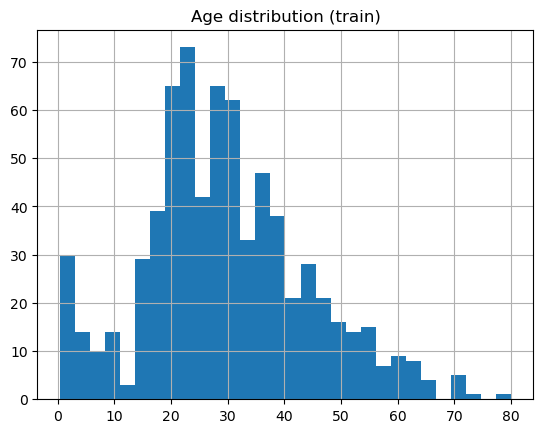


[LogisticRegression] CV Accuracy: mean=0.8249, std=0.0111, scores=[0.838  0.8202 0.809  0.8202 0.8371]

[RandomForest] CV Accuracy: mean=0.8058, std=0.0330, scores=[0.8659 0.7753 0.7809 0.7921 0.8146]

[GradientBoosting] CV Accuracy: mean=0.8361, std=0.0159, scores=[0.8659 0.8258 0.8202 0.8371 0.8315]
Fitting 5 folds for each of 25 candidates, totalling 125 fits

[Best RF params]
{'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': None}
Best CV Accuracy: 0.8473

Saved: C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\submission_from_model.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [3]:
# Titanic 생존자 분석/예측 (Windows 경로 버전)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance


# -----------------------------
# 0) 데이터 로드 (사용자 제공 경로)
# -----------------------------
TRAIN_PATH = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\train.csv"
TEST_PATH  = r"C:\Users\a0916\OneDrive\바탕 화면\DartB_Titanic\test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("train:", train.shape, "test:", test.shape)
print(train.head())
print(test.head())

OUTPUT_DIR = Path(TRAIN_PATH).parent  # 같은 폴더에 결과 저장


# -----------------------------
# 1) EDA (기초 확인)
# -----------------------------
def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    miss_cnt = df.isna().sum()
    miss_rate = (miss_cnt / len(df)).round(4)
    out = pd.DataFrame({"missing_count": miss_cnt, "missing_rate": miss_rate})
    return out.sort_values("missing_rate", ascending=False)

print("\n[Train Missing]")
print(missing_table(train))

print("\n[Test Missing]")
print(missing_table(test))

print("\n[Target distribution: Survived]")
print(train["Survived"].value_counts(normalize=True))

for col in ["Sex", "Pclass", "Embarked"]:
    tmp = train.groupby(col)["Survived"].mean().sort_values(ascending=False)
    print(f"\n[Survival rate by {col}]")
    print(tmp)

plt.figure()
train["Age"].hist(bins=30)
plt.title("Age distribution (train)")
plt.show()


# -----------------------------
# 2) 피처 엔지니어링 Transformer
# -----------------------------
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ticket_count_ = None

    @staticmethod
    def _extract_title(name: str) -> str:
        m = re.search(r",\s*([A-Za-z]+)\.", str(name))
        return m.group(1) if m else "Unknown"

    @staticmethod
    def _simplify_title(title: str) -> str:
        title = str(title)
        rare = {"Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"}
        if title in rare:
            return "Rare"
        if title in {"Mlle", "Ms"}:
            return "Miss"
        if title == "Mme":
            return "Mrs"
        return title

    def fit(self, X, y=None):
        X_ = X.copy()
        self.ticket_count_ = X_["Ticket"].value_counts()
        return self

    def transform(self, X):
        X_ = X.copy()

        X_["Title"] = X_["Name"].apply(self._extract_title).apply(self._simplify_title)

        X_["FamilySize"] = X_["SibSp"].fillna(0) + X_["Parch"].fillna(0) + 1
        X_["IsAlone"] = (X_["FamilySize"] == 1).astype(int)

        X_["CabinDeck"] = X_["Cabin"].fillna("U").astype(str).str[0]

        X_["TicketGroupSize"] = X_["Ticket"].map(self.ticket_count_).fillna(1).astype(int)

        X_["FarePerPerson"] = X_["Fare"] / X_["FamilySize"].replace(0, 1)
        X_["LogFare"] = np.log1p(X_["Fare"])

        drop_cols = ["Name", "Ticket", "Cabin"]
        X_ = X_.drop(columns=[c for c in drop_cols if c in X_.columns])

        return X_


# -----------------------------
# 3) 전처리 파이프라인
# -----------------------------
TARGET = "Survived"
X = train.drop(columns=[TARGET])
y = train[TARGET]

numeric_features = ["Age", "SibSp", "Parch", "Fare", "FamilySize", "TicketGroupSize", "FarePerPerson", "LogFare"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title", "CabinDeck"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


# -----------------------------
# 4) 모델 평가 (Stratified K-Fold)
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, name="model"):
    pipe = Pipeline(steps=[
        ("feat", TitanicFeatureEngineer()),
        ("prep", preprocess),
        ("model", model),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    print(f"\n[{name}] CV Accuracy: mean={scores.mean():.4f}, std={scores.std():.4f}, scores={np.round(scores,4)}")
    return pipe

lr_pipe = evaluate_model(LogisticRegression(max_iter=1000), "LogisticRegression")
rf_pipe = evaluate_model(RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1), "RandomForest")
gb_pipe = evaluate_model(GradientBoostingClassifier(random_state=42), "GradientBoosting")


# -----------------------------
# 5) RandomForest 튜닝(예시)
# -----------------------------
rf_tune_pipe = Pipeline(steps=[
    ("feat", TitanicFeatureEngineer()),
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [200, 400, 800],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    rf_tune_pipe,
    param_distributions=param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)
print("\n[Best RF params]")
print(search.best_params_)
print(f"Best CV Accuracy: {search.best_score_:.4f}")

best_model = search.best_estimator_


# -----------------------------
# 6) 최종 학습 → 예측 → 제출파일 저장
# -----------------------------
best_model.fit(X, y)
test_pred = best_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred.astype(int),
})

out_path = OUTPUT_DIR / "submission_from_model.csv"
submission.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"\nSaved: {out_path}")
print(submission.head())



plt.show()


[Top 20 important features (One-Hot 이후 기준)]
            feature  importance_mean  importance_std
18         Title_Mr         0.184961        0.008999
10         Pclass_3         0.079461        0.006391
6     FarePerPerson         0.066293        0.007867
0               Age         0.041227        0.005077
20       Title_Rare         0.013318        0.001526
30      CabinDeck_U         0.006135        0.001780
7           LogFare         0.005088        0.002385
5   TicketGroupSize         0.004789        0.002441
3              Fare         0.004564        0.002371
17       Title_Miss         0.004265        0.000935
23      CabinDeck_B         0.002993        0.000529
4        FamilySize         0.002768        0.002044
13       Embarked_C         0.001945        0.001120
15       Embarked_S         0.001272        0.001351
22      CabinDeck_A         0.001122        0.000000
26      CabinDeck_E         0.001048        0.000280
16     Title_Master         0.000374        0.000785
2

C:\Users\a0916\AppData\Local\Temp\ipykernel_28208\3249158934.py:57: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0916\AppData\Local\Temp\ipykernel_28208\3249158934.py:57: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\a0916\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\a0916\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


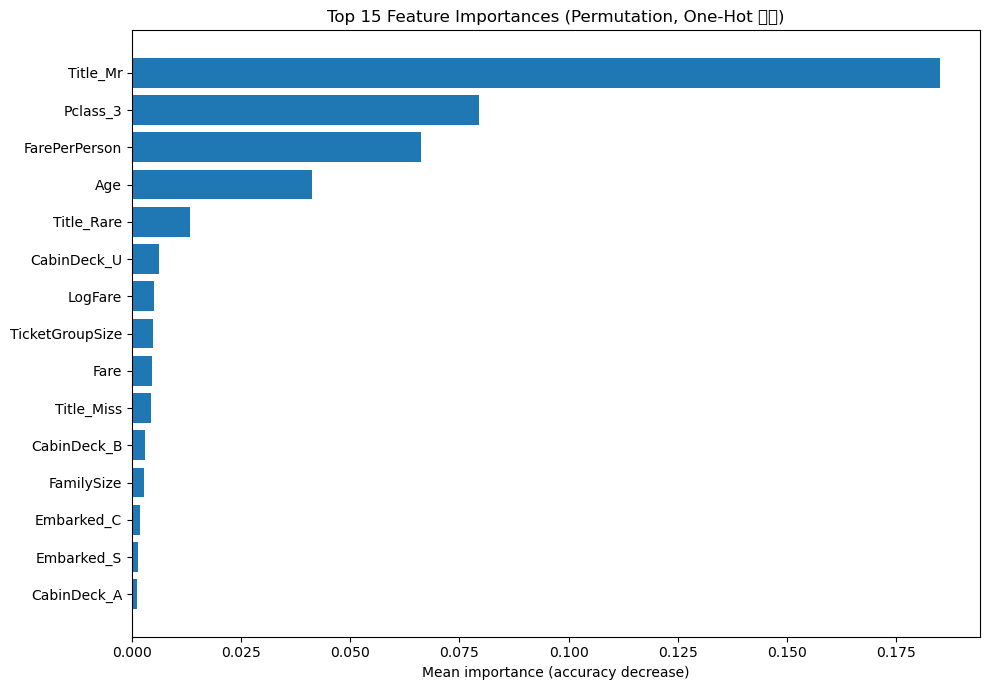

In [4]:
# -----------------------------
# 7) 해석: Permutation Importance (원핫 이후 피처 기준)  ✅
# -----------------------------
from sklearn.inspection import permutation_importance
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt

# 파이프라인에서 단계 꺼내기
feat_step = best_model.named_steps["feat"]
prep_step = best_model.named_steps["prep"]
clf       = best_model.named_steps["model"]

# 1) Feature Engineering 적용 (DataFrame 유지)
X_fe = feat_step.transform(X)

# 2) 전처리(원핫 포함) 적용
X_tr = prep_step.transform(X_fe)

# 3) sparse면 dense로 변환 (트리 모델에서 안전하게)
if sp.issparse(X_tr):
    X_tr = X_tr.toarray()

# 4) 변환 후 피처 이름 만들기
#    (numeric_features, categorical_features는 위에서 정의한 그대로 사용)
ohe = prep_step.named_transformers_["cat"].named_steps["onehot"]
feat_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

# 안전 체크: 길이 불일치하면 바로 알려주기
if X_tr.shape[1] != len(feat_names):
    raise ValueError(f"피처 개수 불일치: X_tr={X_tr.shape[1]}, feat_names={len(feat_names)}")

# 5) 분류기만 대상으로 permutation importance 계산
perm = permutation_importance(
    clf, X_tr, y,
    n_repeats=15,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\n[Top 20 important features (One-Hot 이후 기준)]")
print(imp.head(20))

# 6) 시각화
plt.figure(figsize=(10, 7))
topk = imp.head(15).iloc[::-1]
plt.barh(topk["feature"], topk["importance_mean"])
plt.title("Top 15 Feature Importances (Permutation, One-Hot 기준)")
plt.xlabel("Mean importance (accuracy decrease)")
plt.tight_layout()
plt.show()